In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250523 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

if __name__ == "__main__":
    base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov"
    # "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused" #'/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon' #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
    # save_path = os.path.join(base_folder, 'paret')
    failed_paths_file = None #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed.txt" #'/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed_brws.txt'  # File containing failed paths

    force_rescan_rec_files = [
        # ('2023-10-01', '001'),
        # ('2023-10-02', '002'),
        # Add more as needed
    ]
    rescan_threshold_days = 0.000001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

    log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                              force_rescan_rec_files=force_rescan_rec_files,
                              rescan_threshold_days=rescan_threshold_days)


Log for ZIcI1_1mW saved at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/folder_log.parquet
Log for ZIcI1_00mW saved at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW/folder_log.parquet
Log for ZIcI1_5mW saved at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW/folder_log.parquet
Log for ZIcI1_10mW saved at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW/folder_log.parquet
Log for ZIcI1_0mW saved at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW/folder_log.parquet


In [2]:
sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1"
all_df = read_all_parquet_files(base_folder)

In [3]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   # pc.equal(table['mir_generate_param'], '0'),
   # pc.equal(table['sync'], '1'),
#    # pc.not_equal(table['sync'], '3'),
   # pc.equal(table['com'], '1'),
   # pc.equal(table['com_vis'], '0'),
   # # pc.equal(table['v1'], '1'),
#    pc.equal(table['dannce'], '0'),
   # pc.equal(table['dannce_vis'], '1'),
   # pc.equal(table['social'], '1'),
   # pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync_com'], '1'),
   #mini_rec_sync
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)



# Apply the filter and print the results
for_com = table.filter(filter_mask)

# Print each row of the filtered table
print(for_com.to_pandas())  # This will display the filtered data in a familiar pandas-like format


  mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                  0    0             0            0   0       0      0   
1                  0    0             0            0   0       0      0   
2                  0    0             0            0   0       0      0   
3                  0    0             0            0   0       0      0   
4                  0    0             0            0   0       0      0   

  miniscope test after_oxytocin before_oxytocin dannce dannce_vis  \
0         0    0              0               0      0          0   
1         0    0              0               0      0          0   
2         0    0              0               0      0          0   
3         0    0              0               0      0          0   
4         0    0              0               0      0          0   

  mini_rec_sync    rec_file                   scan_time  \
0             0   ZIcI1_1mW  2025-11-03T13:03:50.575741   
1             0 

In [4]:
# Convert and flatten the ChunkedArray
experiment_paths = for_com["rec_path"].to_pylist()

# Print each path
for path in experiment_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW


In [5]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_mirgenparam
filtered_table = for_com
sequential_process_and_update_mirgenparam(filtered_table, base_folder)

Found 6 calibration files.
Frame count: 18000
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam1_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam2_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam3_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam4_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam5_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/calib_before/hires_cam6_params.mat
Data saved to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/2025_10_31_ZIcI1_1mW_calib_before_label3d_dannce.mat
mir_generate_param ran successfully.
Updated Parquet file at /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/folder_log.parquet with new status.
Found 6 calibration files.
Frame cou

Processing: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW
Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/videos/6cam_sync.png


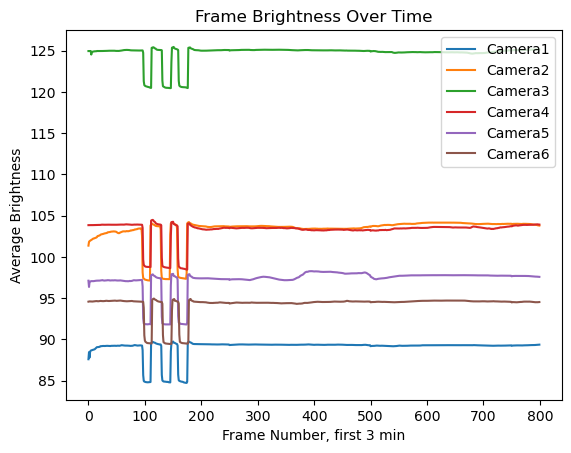

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW: {'Camera1': [97, 130, 159], 'Camera2': [96, 129, 158], 'Camera3': [98, 131, 160], 'Camera4': [97, 130, 159], 'Camera5': [97, 130, 159], 'Camera6': [99, 132, 161]}
Processed drop frames: {'Camera1': 97, 'Camera2': 96, 'Camera3': 98, 'Camera4': 97, 'Camera5': 97, 'Camera6': 99}
96
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/df_synced_2025_10_31_ZIcI1_1mW_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/2025_10_31_ZIcI1_1mW_calib_before_label3d_dannce.mat 
Moved prior calibration file /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/2025_10_31_ZIcI1_1mW_calib_before_label3d_dannce.mat to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_1mW/prev_calib
please mannu

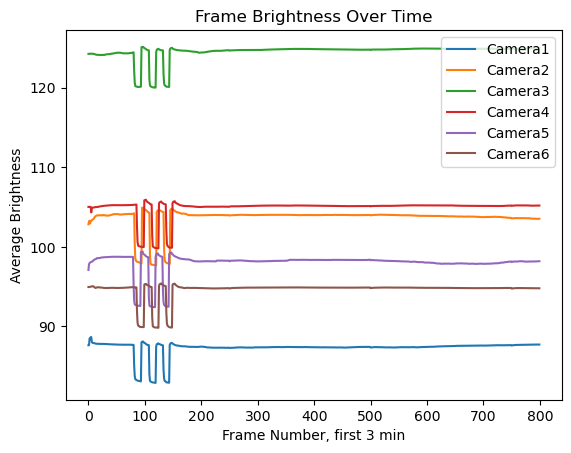

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW: {'Camera1': [81, 108, 133], 'Camera2': [82, 109, 134], 'Camera3': [81, 108, 133], 'Camera4': [86, 113, 138], 'Camera5': [80, 81, 107, 132], 'Camera6': [86, 113, 138]}
Processed drop frames: {'Camera1': 81, 'Camera2': 82, 'Camera3': 81, 'Camera4': 86, 'Camera5': 81, 'Camera6': 86}
81
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW/df_synced_2025_10_31_ZIcI1_00mW_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW/2025_10_31_ZIcI1_00mW_calib_before_label3d_dannce.mat 
Moved prior calibration file /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW/2025_10_31_ZIcI1_00mW_calib_before_label3d_dannce.mat to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_00mW/prev_calib

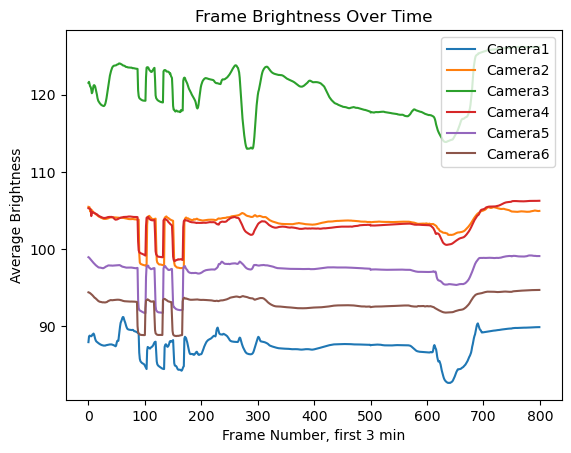

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW: {'Camera1': [90], 'Camera2': [90, 120, 121, 151, 152], 'Camera3': [88, 119, 150], 'Camera4': [88, 119, 150], 'Camera5': [88, 118, 119, 149, 150], 'Camera6': [87]}
Processed drop frames: {'Camera1': 90, 'Camera2': 90, 'Camera3': 88, 'Camera4': 88, 'Camera5': 88, 'Camera6': 87}
87
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW/df_synced_2025_10_31_ZIcI1_5mW_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW/2025_10_31_ZIcI1_5mW_calib_before_label3d_dannce.mat 
Moved prior calibration file /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW/2025_10_31_ZIcI1_5mW_calib_before_label3d_dannce.mat to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_5mW/prev_calib
please mannu

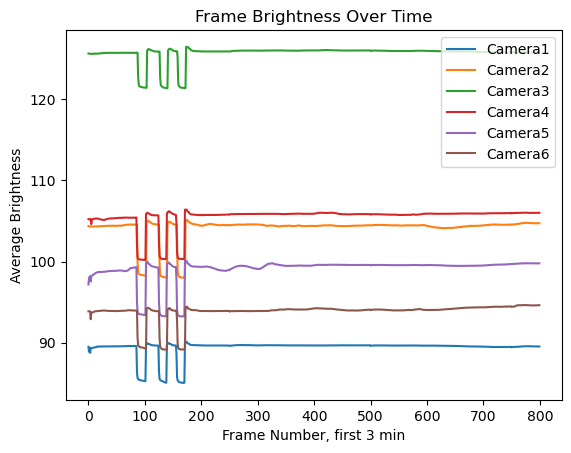

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW: {'Camera1': [86, 125, 157], 'Camera2': [87, 126, 158], 'Camera3': [88, 127, 159], 'Camera4': [86, 125, 157], 'Camera5': [86, 125, 157], 'Camera6': [87, 126, 158]}
Processed drop frames: {'Camera1': 86, 'Camera2': 87, 'Camera3': 88, 'Camera4': 86, 'Camera5': 86, 'Camera6': 87}
86
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW/df_synced_2025_10_31_ZIcI1_10mW_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW/2025_10_31_ZIcI1_10mW_calib_before_label3d_dannce.mat 
Moved prior calibration file /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW/2025_10_31_ZIcI1_10mW_calib_before_label3d_dannce.mat to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_10mW/prev_calib
ple

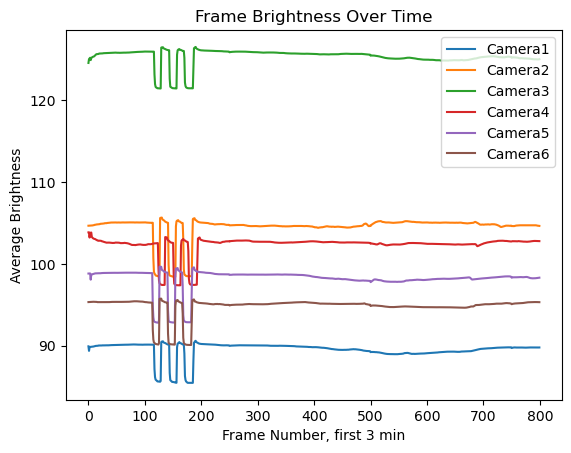

Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW: {'Camera1': [117, 144, 171], 'Camera2': [115, 142, 169], 'Camera3': [117, 144, 171], 'Camera4': [124, 151, 178], 'Camera5': [114, 141, 168], 'Camera6': [114, 141, 168]}
Processed drop frames: {'Camera1': 117, 'Camera2': 115, 'Camera3': 117, 'Camera4': 124, 'Camera5': 114, 'Camera6': 114}
114
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW/df_synced_2025_10_31_ZIcI1_0mW_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW/2025_10_31_ZIcI1_0mW_calib_before_label3d_dannce.mat 
Moved prior calibration file /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW/2025_10_31_ZIcI1_0mW_calib_before_label3d_dannce.mat to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/25Nov/2025_10_31/ZIcI1_0mW/prev_calib

In [6]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_sync

# sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800) #threshold=2, max_frames=300, min_frame=0
try:
    sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800)
except Exception as e:
    print(f"Skipping due to error: {e}")

In [ ]:
# # social com

# from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs
# filtered_table=for_com

# dispatch_slurm_jobs(
#     base_path=base_folder,
#     table=filtered_table,
#     slurm_launch_f=ile="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py",
#     predict_flag="--predict_com",
#     conda_env="sdannce",
#     partition="scavenger-gpu",
#     dry_run=False,
#     max_workers=6,
# )

Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_s

In [11]:
# single com

from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs
filtered_table = for_com
dispatch_slurm_jobs(
    base_path=base_folder,
    table=filtered_table,
    slurm_launch_file="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py",
    predict_flag="--predict_com",
    conda_env="sdannce",
    partition="scavenger-gpu",
    dry_run=False,
    max_workers=6,
)

Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_base03 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/01mouse_base03

Specified a single expdir; running predictions ...
Running predictions on 1 experiments ...
Running command:  cd /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_base03
dannce predict com /hpc/group/tdunn/tqxli/sdannce_scripts/configs/com_mouse_config.yaml --com-predict-weights=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/COM/checkpoint-epoch20.pth --com-predict-dir=COM/predict00 --max-num-samples 100000 --batch-size=1
Slurm out: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_base03/slurm/predict_com_02mouse_base03.out
Submitted batch job 38416356

Specified a single expdir; running predictions ...
Running predictions on 1 experiments ...
Running command:  cd /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto
dannce predict com /hpc/group/tdunn/tqxli/sdannce_scripts/configs/com_mouse_config.yaml --com-predict-weights=/hpc/group/tdunn/tqxli/sdannce_scripts/weights/COM/c

/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/01mouse_base02
plotting com_traga for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/01mouse_base02


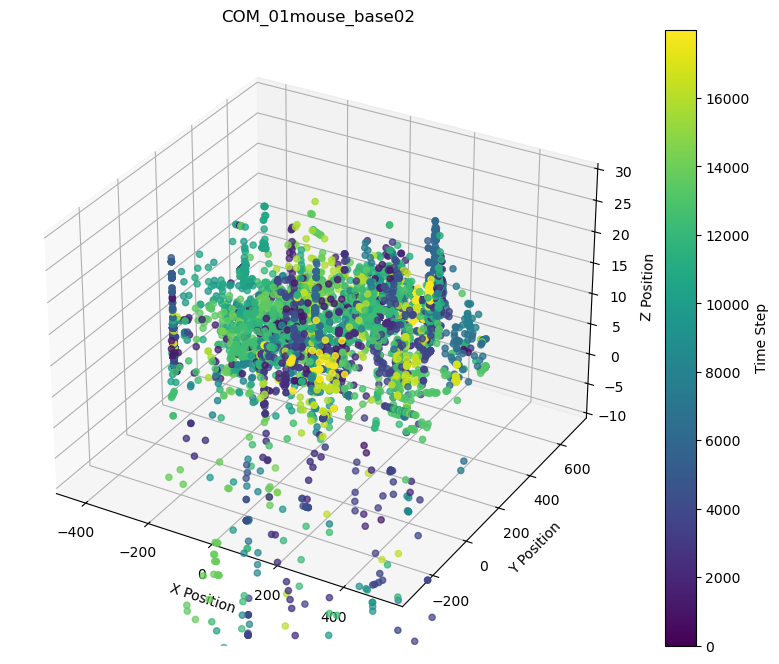

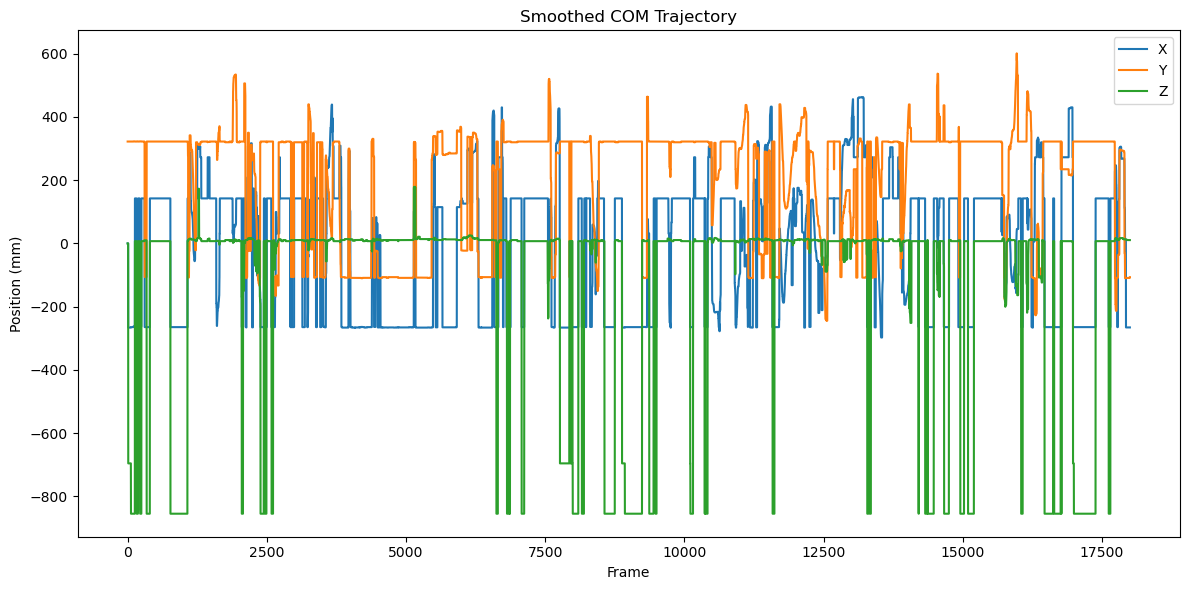

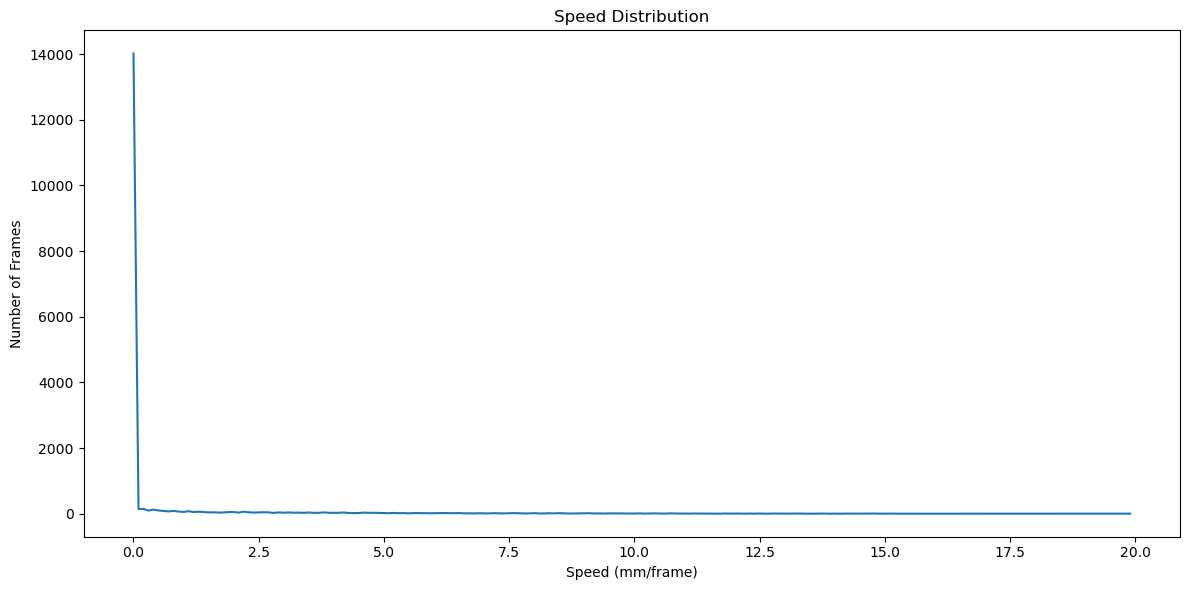

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/01mouse_base02/COM/predict00/vis


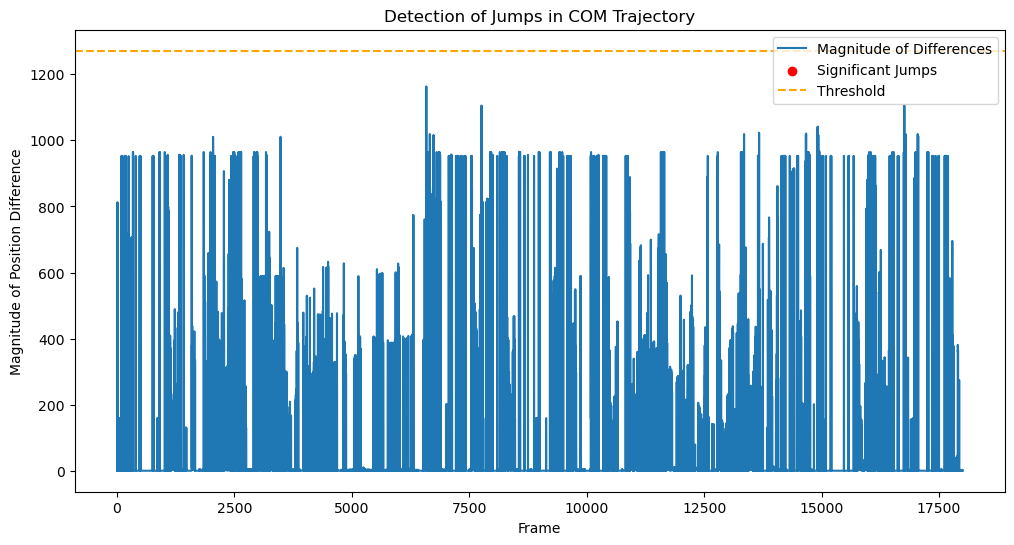

saved into npy. Frames with significant jumps: []
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto
plotting com_traga for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto


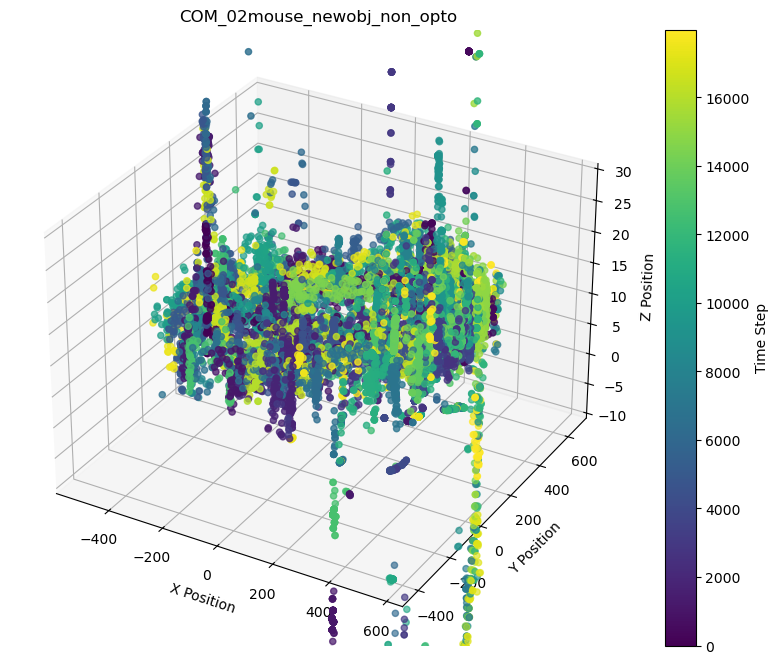

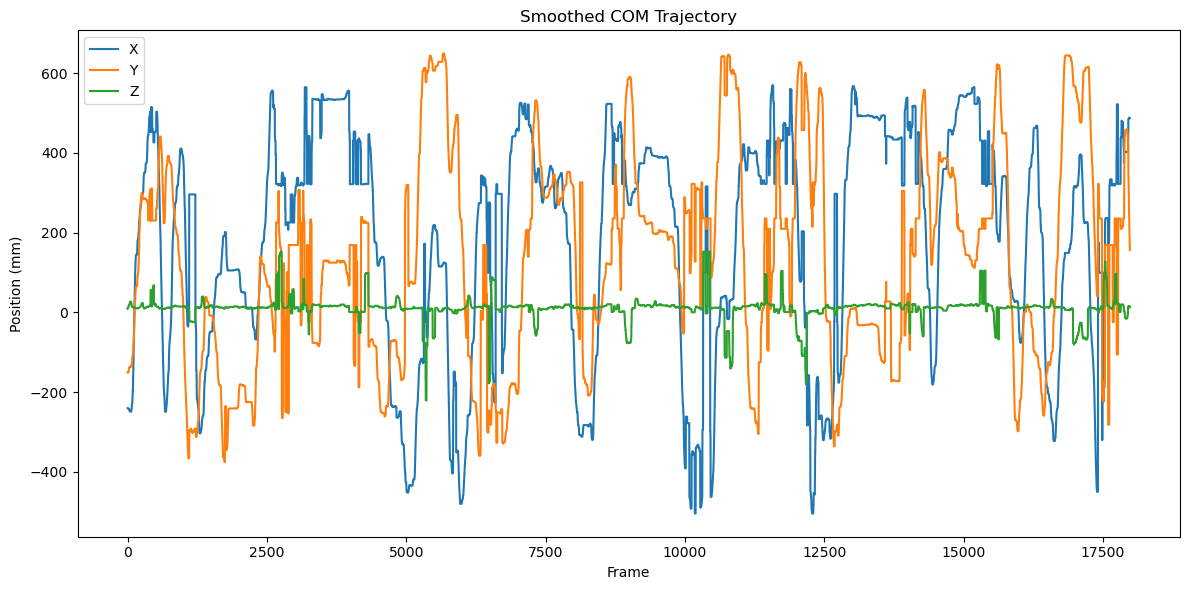

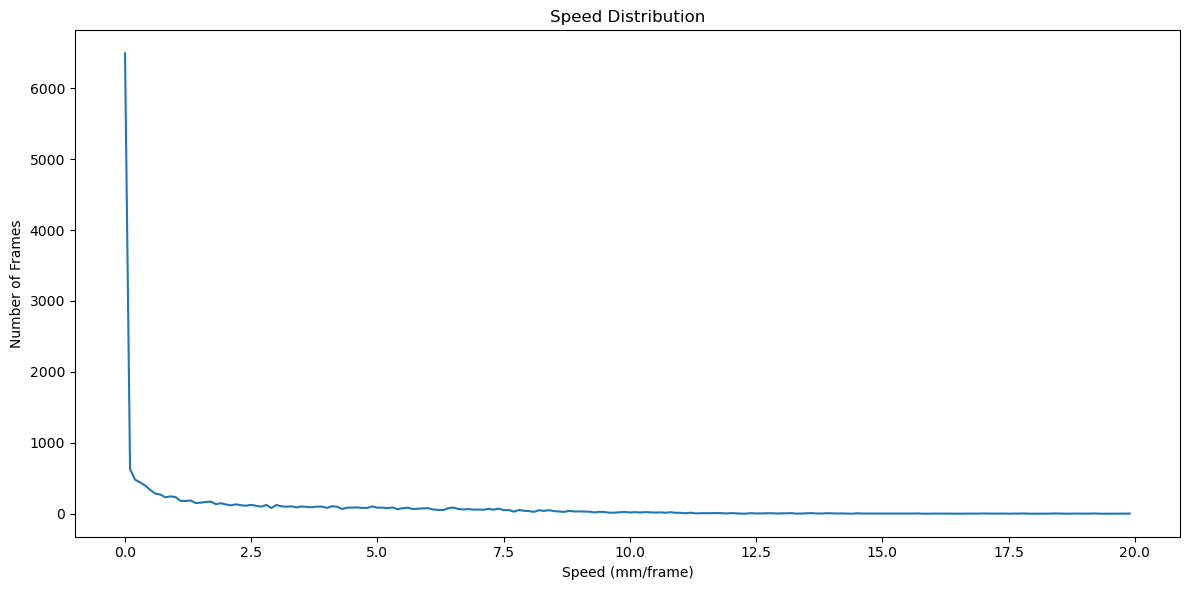

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto/COM/predict00/vis


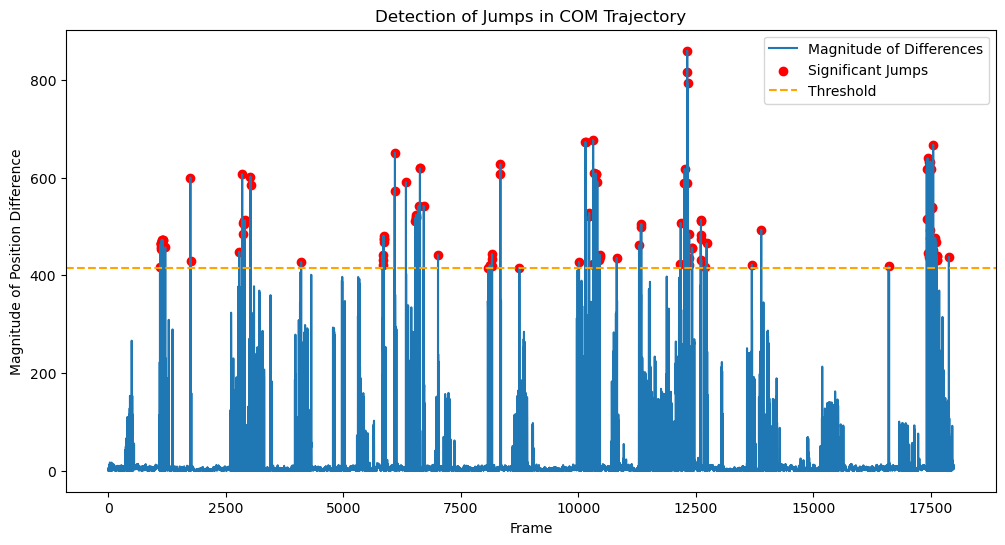

saved into npy. Frames with significant jumps: [ 1102  1113  1114  1126  1127  1132  1134  1135  1136  1137  1146  1162
  1164  1214  1748  1757  2789  2850  2870  2877  2879  2883  2884  2885
  2891  2896  2901  2903  3026  3036  4104  5837  5838  5845  5856  5858
  5859  5860  6095  6099  6333  6533  6540  6543  6547  6602  6630  6631
  6712  7015  8087  8115  8156  8162  8165  8341  8342  8746 10014 10144
 10153 10219 10220 10221 10230 10313 10314 10325 10354 10356 10374 10375
 10403 10447 10454 10457 10815 11290 11328 11338 12164 12176 12257 12260
 12315 12316 12317 12321 12356 12357 12359 12420 12421 12603 12606 12607
 12608 12612 12683 12727 13689 13889 16599 17409 17425 17426 17435 17443
 17455 17458 17470 17478 17479 17480 17481 17485 17486 17487 17489 17491
 17493 17494 17495 17501 17511 17528 17540 17546 17590 17610 17623 17624
 17625 17626 17880]
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_base02
plotting com_traga for /hpc/group/tdunn

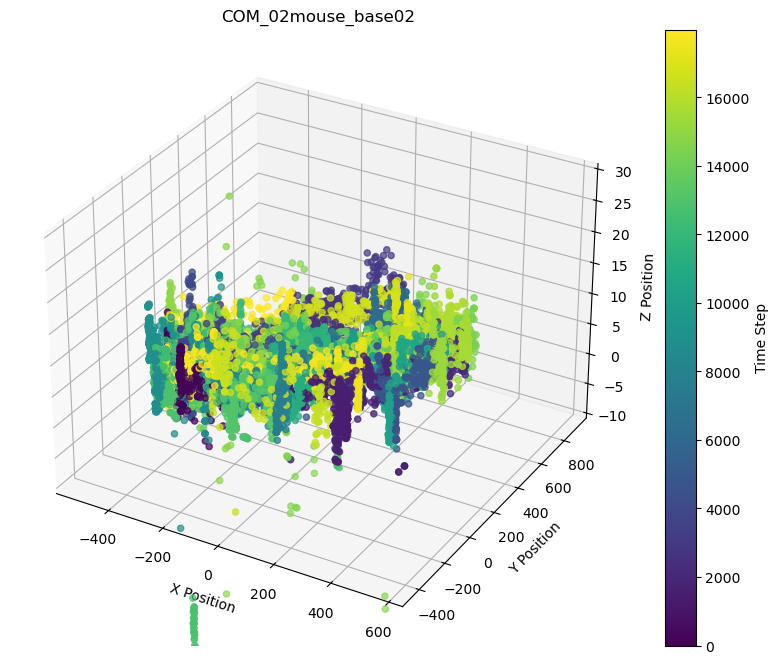

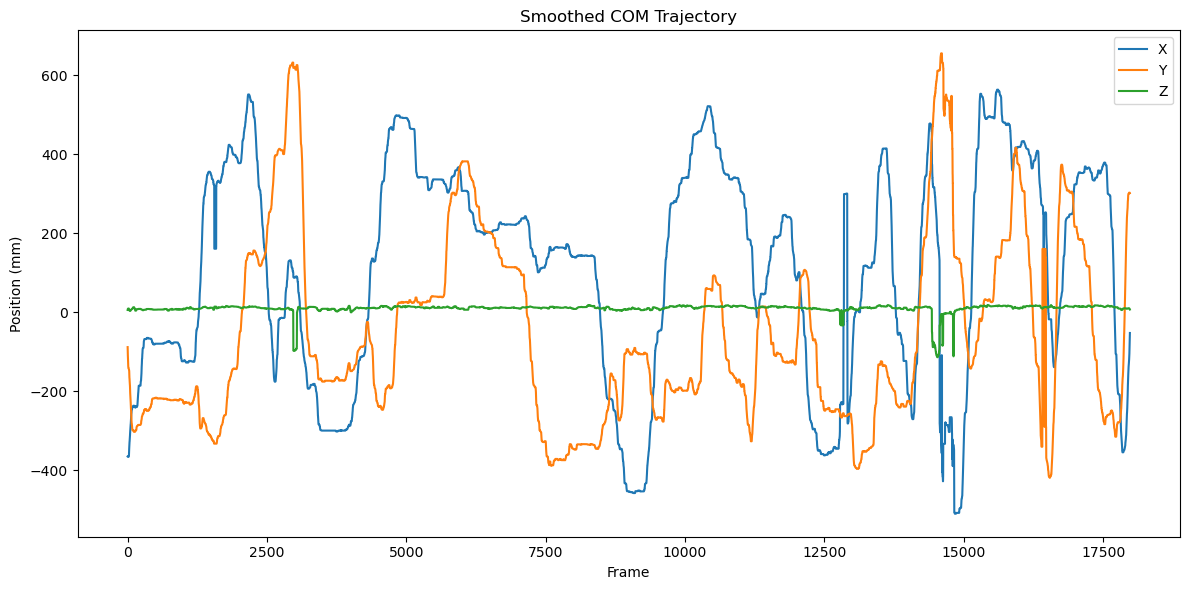

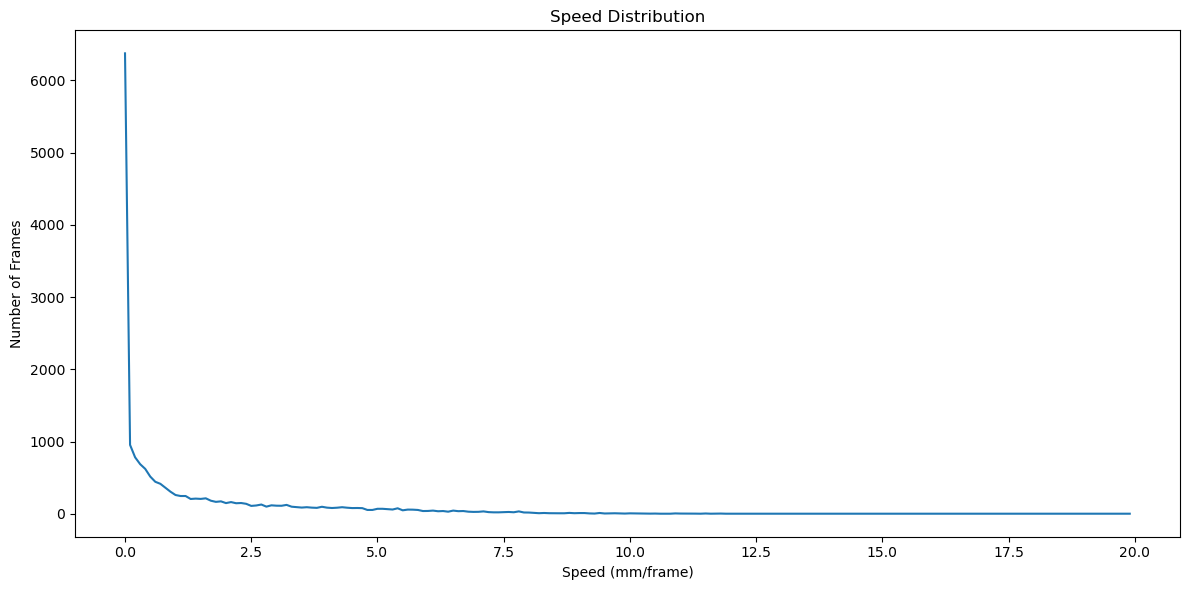

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_base02/COM/predict00/vis


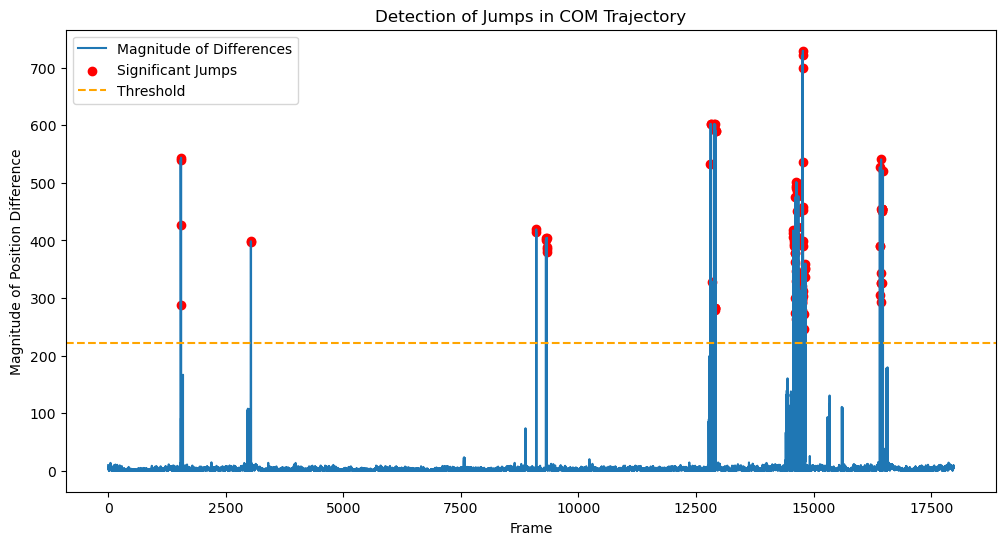

saved into npy. Frames with significant jumps: [ 1541  1543  1544  1550  3035  3037  9099  9103  9308  9315  9324  9326
  9327  9329 12806 12809 12810 12817 12848 12879 12881 12882 12886 12907
 12909 12910 12911 12913 12921 12922 14564 14569 14570 14587 14588 14589
 14601 14602 14603 14607 14609 14610 14615 14616 14618 14623 14624 14628
 14632 14633 14634 14635 14637 14638 14639 14641 14643 14657 14659 14671
 14675 14677 14678 14679 14681 14683 14684 14685 14686 14688 14689 14691
 14692 14694 14697 14699 14700 14702 14704 14711 14713 14734 14735 14739
 14740 14749 14751 14754 14755 14757 14760 14764 14767 14769 14770 14771
 14772 14773 14775 14776 14777 14778 14779 14785 14786 14800 14821 14823
 14825 14827 16408 16418 16419 16420 16429 16433 16436 16437 16438 16443
 16445 16447 16451 16453 16454 16455 16458 16462 16476]
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/02mouse_base01
plotting com_traga for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_o

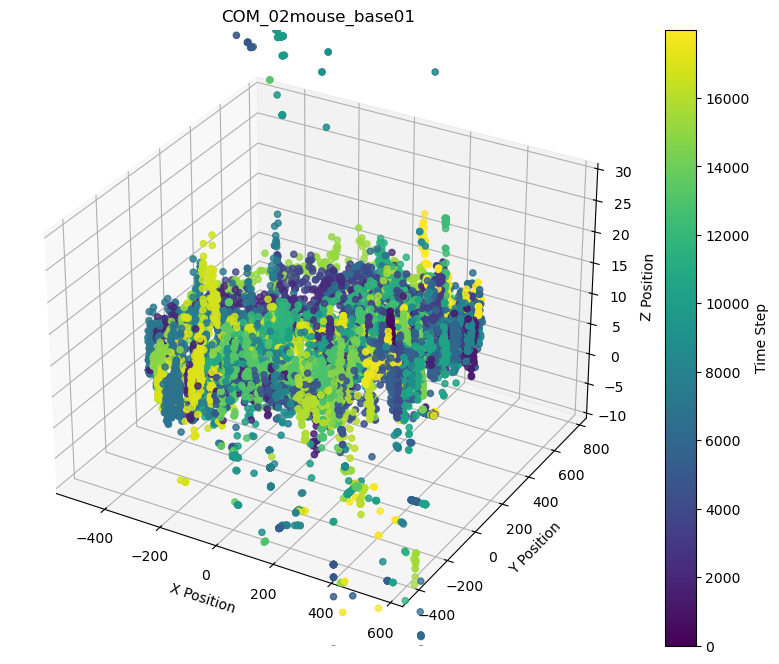

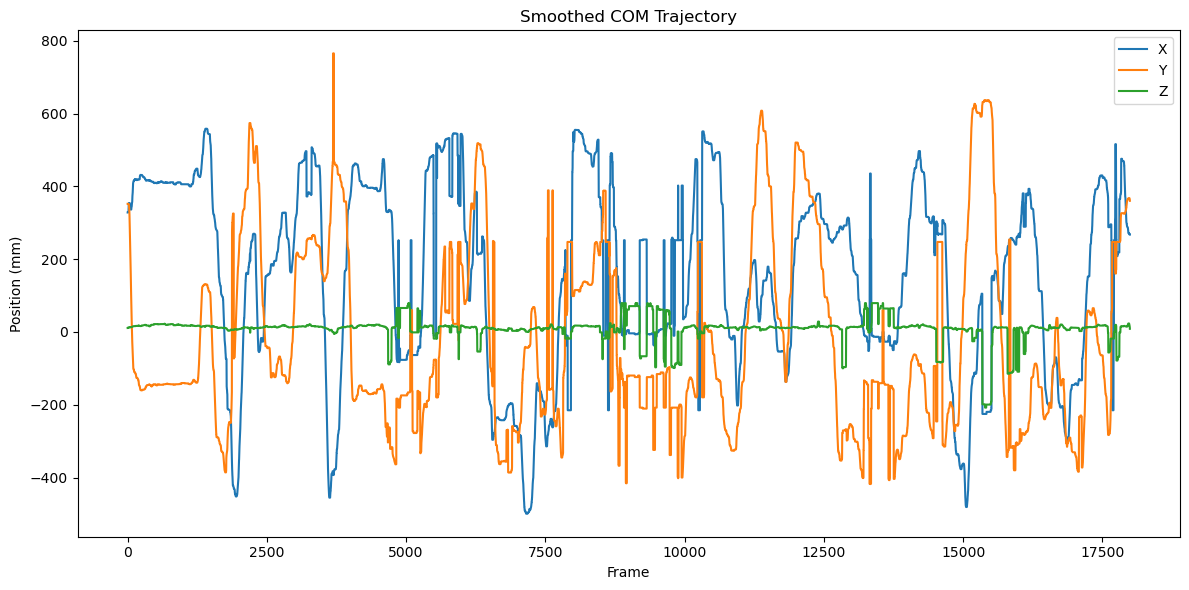

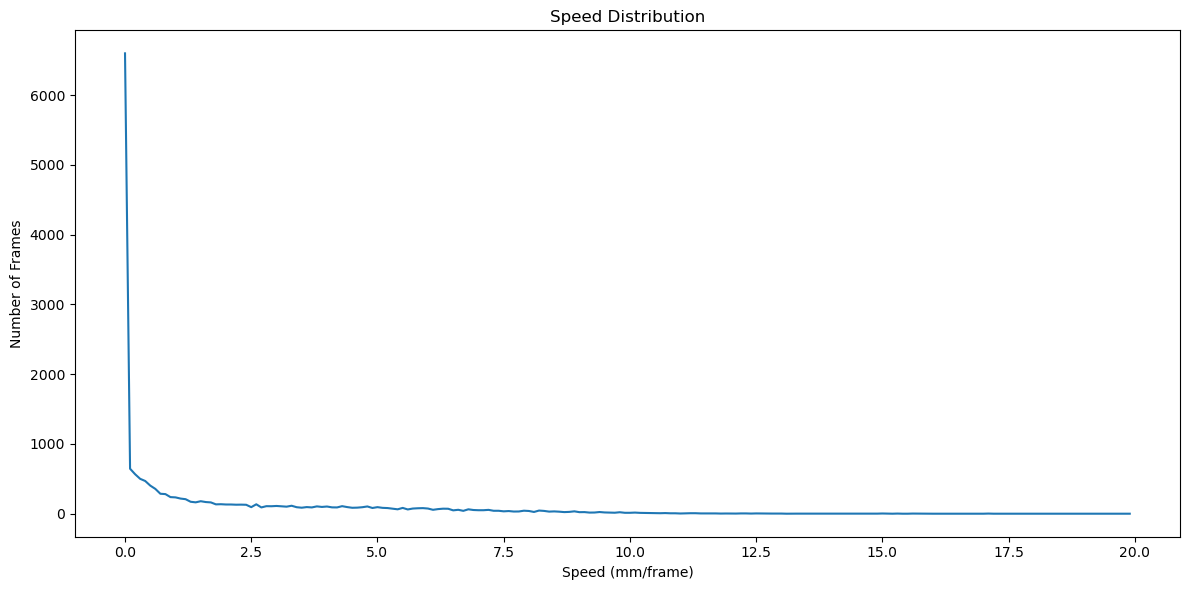

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/02mouse_base01/COM/predict00/vis


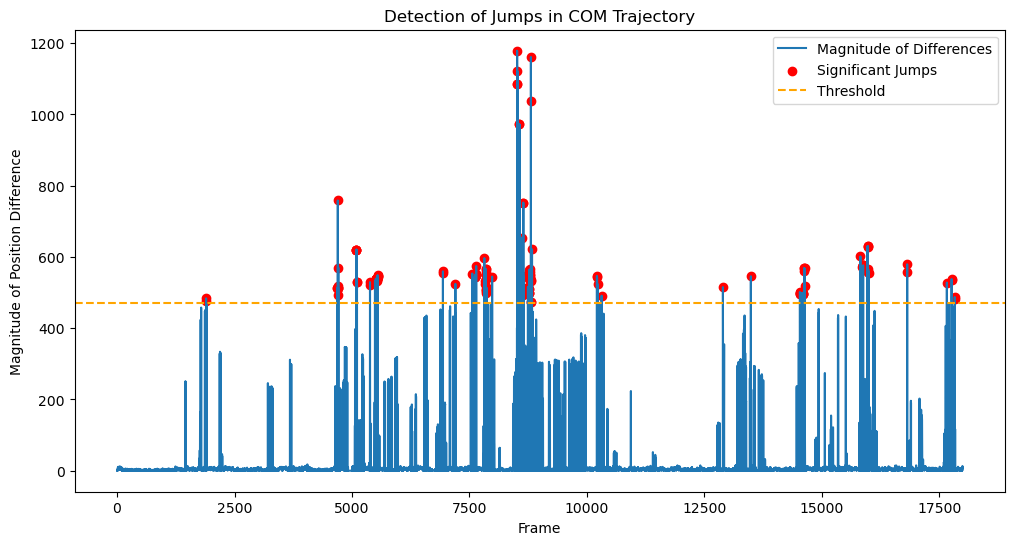

saved into npy. Frames with significant jumps: [ 1893  1895  4687  4688  4696  4697  4698  4701  4703  4705  4709  5090
  5091  5094  5095  5098  5106  5382  5383  5489  5502  5503  5504  5505
  5506  5508  5517  5518  5526  5527  5532  5533  5534  5539  5541  5543
  5544  5545  5548  6934  6935  7200  7560  7615  7617  7619  7624  7628
  7630  7631  7636  7637  7638  7641  7643  7816  7825  7826  7842  7843
  7849  7850  7852  7857  7859  7860  7861  7865  7982  8514  8515  8520
  8521  8560  8563  8610  8633  8642  8643  8646  8647  8650  8744  8762
  8763  8764  8765  8766  8767  8774  8778  8781  8782  8783  8784  8786
  8787  8803  8804  8806  8807  8811  8812  8831 10212 10215 10230 10312
 12893 13488 14531 14532 14533 14537 14538 14545 14546 14549 14550 14553
 14555 14556 14563 14567 14569 14572 14573 14578 14579 14582 14584 14587
 14588 14592 14600 14620 14623 14627 14632 14633 15819 15847 15875 15876
 15877 15878 15972 15974 15976 15977 15986 15987 15991 15992 16814 16815
 176

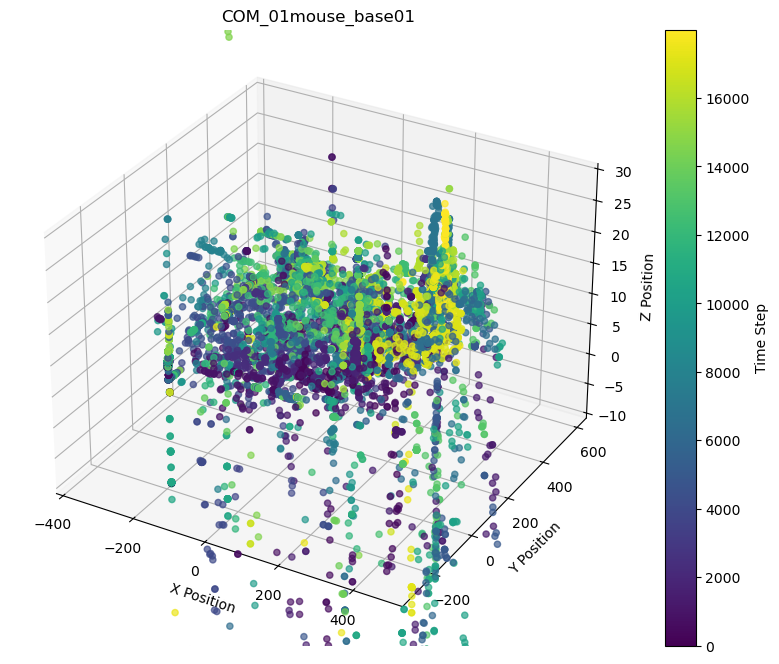

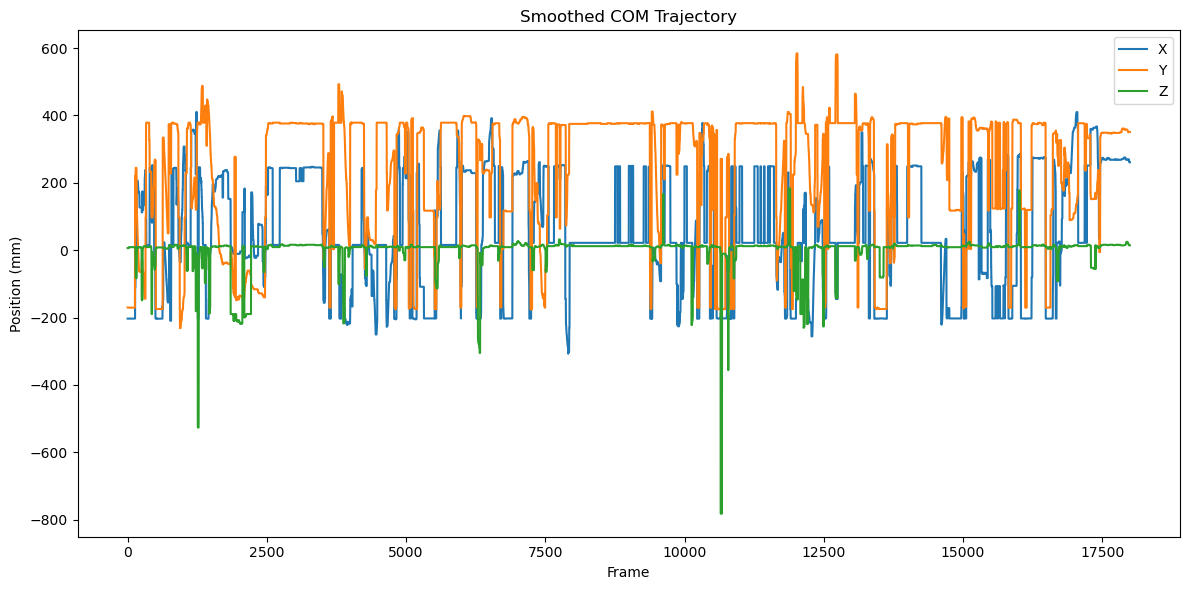

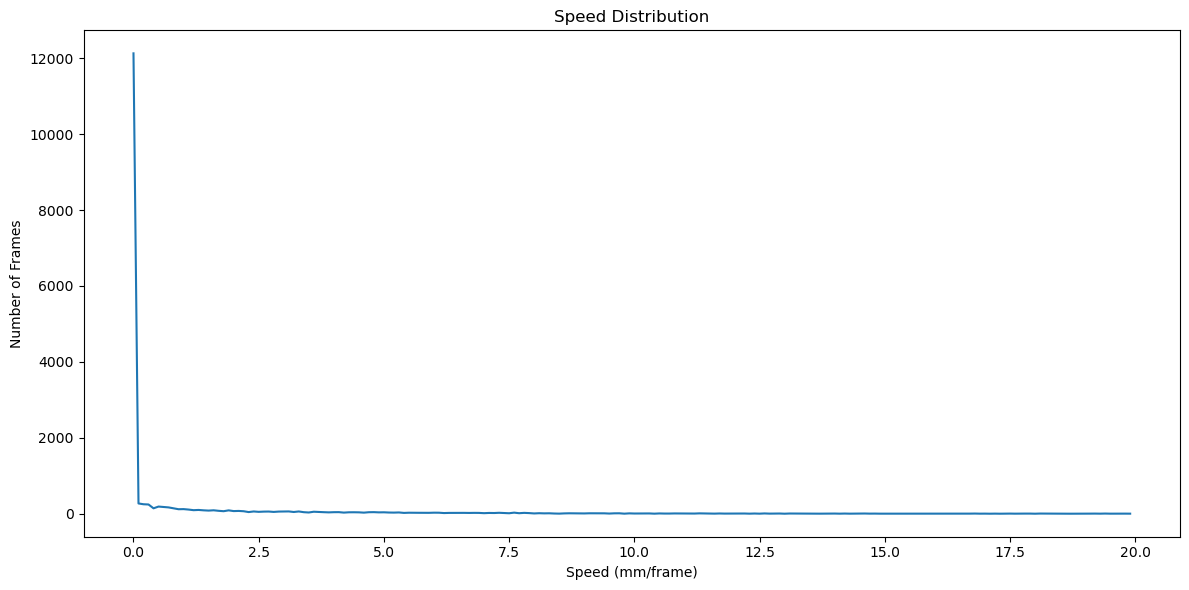

Analysis complete. Plots saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/01mouse_base01/COM/predict00/vis


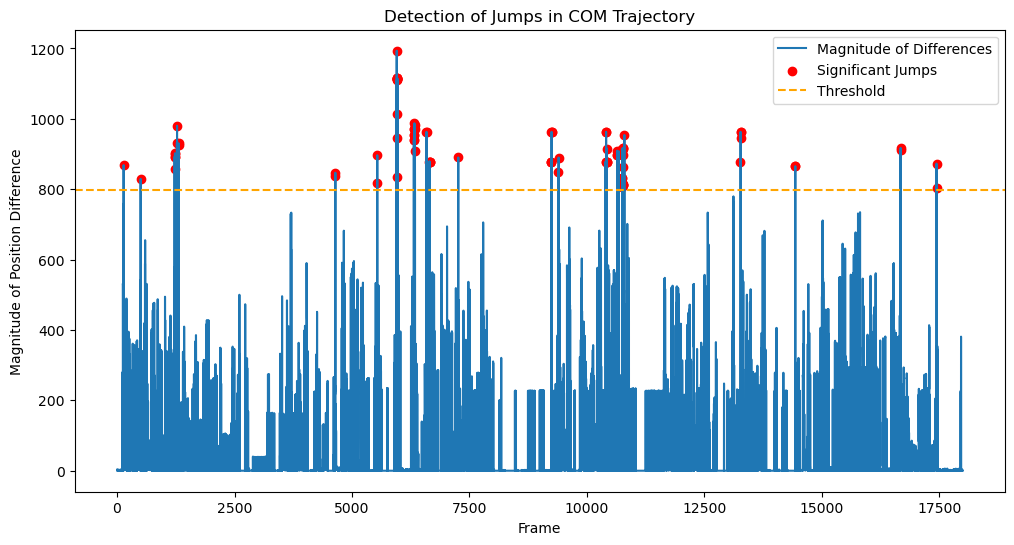

saved into npy. Frames with significant jumps: [  140   502  1226  1227  1229  1231  1232  1274  1277  1311  1312  4646
  4647  5537  5539  5951  5953  5954  5956  5957  5959  5961  5962  5964
  5966  5967  5969  6316  6317  6324  6325  6329  6330  6331  6334  6336
  6341  6586  6587  6642  6651  6653  6654  7263  9240  9242  9244  9247
  9249  9251  9396  9399 10397 10398 10409 10410 10422 10423 10424 10425
 10645 10646 10648 10671 10682 10683 10755 10756 10758 10760 10761 10762
 10763 10766 10768 10769 10771 10774 10799 13270 13271 13272 13273 14435
 14437 16679 16682 17443 17444]


In [6]:
# single com vis

from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = for_com
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all(base_path,perform_jump_indices=True) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [10]:
# single dannce predict
# below is to exclude the bad com dir mannually, by inserting things in a txt file...


from concurrent.futures import ThreadPoolExecutor
import os

for_dannce = for_com

slurm_launch_file = "/hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py"
# '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'

def check_expdir(expdir):
    if not os.path.exists(expdir):
        print(f"Skipping: Experiment directory {expdir} does not exist")
        return None  # Return None or skip processing this directory
    return expdir

# Function to create the full expdir path and print the command for dry-run
def run_command(base_path, date_folder, rec_file, partition='scavenger-gpu', dry_run=True):
    expdir_path = os.path.join(base_path, date_folder, rec_file)
    
    # Check if the experiment directory exists before running the command
    if check_expdir(expdir_path) is None:
        return  # Skip this execution if the directory does not exist
    
    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_dannce --partition {partition}"  # --allow_overwrite removed by default.

    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)

# Read the list of relative paths to skip from the .txt file
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/bad_com.txt"
# "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25juneon/com_repre.txt"
# '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/1_point_com_rerun.txt'  # Update this to the path of your .txt file
rel_paths_to_skip = set()
with open(txt_file, 'r') as f:
    for line in f:
        rel_path = line.strip()
        if rel_path:
            rel_paths_to_skip.add(rel_path)

# print(rel_paths_to_skip)

# Extract relevant data from the filtered PyArrow Table `for_com_vis`
base_path = base_folder  # Ensure base_folder is defined
# base_path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Adjust this base path as needed

records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce['date_folder'], for_dannce['rec_file'])
]

# Run in parallel with dry-run enabled for testing
max_concurrent_jobs = 4  # Choose how many jobs to run in parallel

dry_run = False  # Set to False to execute commands

with ThreadPoolExecutor(max_workers=max_concurrent_jobs) as executor:
    futures = []
    futures = []
    for record in records:
        # Create the relative path (date_folder/rec_file)
        rel_path = os.path.join(record['date_folder'], record['rec_file'])
        expdir_path = os.path.join(base_path, rel_path)

        if expdir_path in rel_paths_to_skip:
            print(f"Skipping: {rel_path} is in the skip list")
            continue  # Skip this record if it's in the skip list

        # Submit the job to the executor
        futures.append(
            executor.submit(run_command, base_path, record['date_folder'], record['rec_file'], 'scavenger-gpu', dry_run)
        )


Skipping: 2025_10_14/01mouse_base02 is in the skip list
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto --predict_dannce --partition scavenger-gpu
Skipping: 2025_10_13/02mouse_base01 is in the skip list
Skipping: 2025_10_13/01mouse_base01 is in the skip list
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_base02 --predict_dannce --partition scavenger-gpu
Executing command: conda run -n sdannce python /hpc/group/tdunn/lq53/251017_new_dannce_files/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto --predict_dannce --partition scavenger-gpu
Skipping: 2025_10_16/01mouse_base03 is

In [ ]:
# #social path:
# from utlis.vis_valid_utlis.com_trace import plot_com_circle_for_path_social

# # path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4"
# # plot_com_circle_for_path_social(path)


# for_com_vis = for_com
# records = [
#     {
#         'date_folder': date_folder.as_py(),  # Convert to string using as_py()
#         'rec_file': rec_file.as_py()         # Convert to string using as_py()
#     }
#     for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
# ]

# # Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     plot_com_circle_for_path_social(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4
Primary COM file not found; using fallback: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/COM/predict00/com3d0.mat
Saved COM circle plot to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/COM/predict00/vis/com_circle.png
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5
Primary COM file not found; using fallback: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/COM/predict00/com3d0.mat
Saved COM circle plot to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/COM/predict00/vis/com_circle.png
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2
Primary COM file not found; using fallback: 

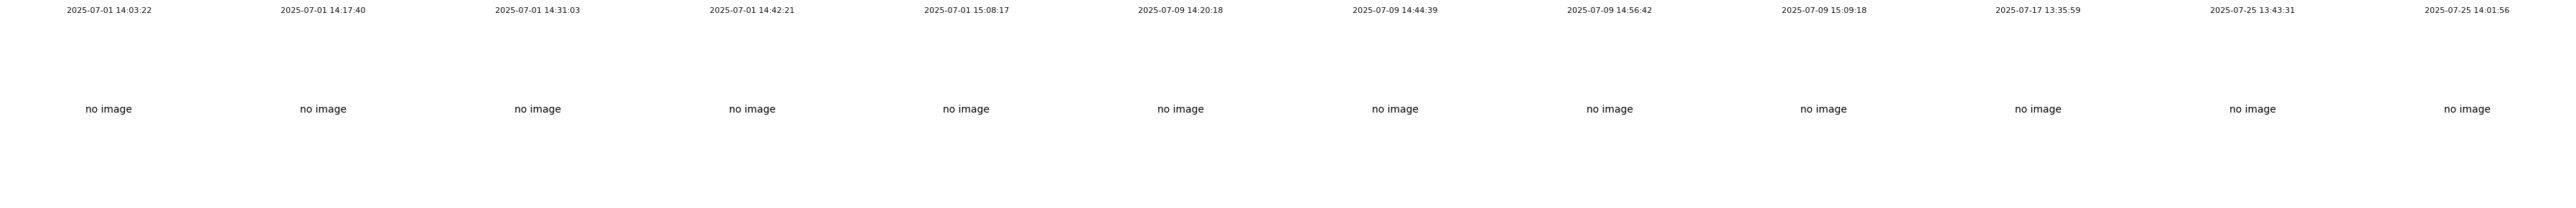

In [ ]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


filtered_table = for_com

# 1. Flatten your rec_paths
rec_paths = filtered_table["rec_path"].to_pylist()
base_paths = [p[0] if isinstance(p, list) else p for p in rec_paths]

# 2. Collect (path, modification time) for each frametimes.mat
sessions = []
for p in base_paths:
    ft = os.path.join(p, "videos", "Camera1", "frametimes.mat")
    if os.path.isfile(ft):
        mtime = os.path.getmtime(ft)
        sessions.append((p, mtime))
    else:
        print(f"Warning: frametimes.mat not found for {p}")

# 3. Sort all sessions by timestamp
sessions.sort(key=lambda x: x[1])

# 4. Plot every session on a single figure
n = len(sessions)
fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
if n == 1:
    axes = [axes]

for ax, (p, mtime) in zip(axes, sessions):
    img_file = os.path.join(p, "COM/predict00/vis", "com_circle.png")
    if os.path.isfile(img_file):
        img = mpimg.imread(img_file)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "no image", ha="center", va="center")
    ts = datetime.fromtimestamp(mtime).strftime("%Y-%m-%d %H:%M:%S")
    ax.set_title(ts, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
# social com vis

# from utlis.vis_valid_utlis.com_trag_updated import plot_com_all
from utlis.vis_valid_utlis.scom_traga_utlis import plot_com_all_social

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all_social(base_path,perform_generate_com_video=True) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/02mouse_base01/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/01mouse_base02/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_base02/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/01mouse_newobj_opto/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/01mouse_base01/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_newobj_no_opto/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_16/02mouse_base03







Prediction file 'save_data_AVG.mat' not found in '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/02mouse_base01'.
Prediction file 'save_data_AVG.mat' not found in '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_objec

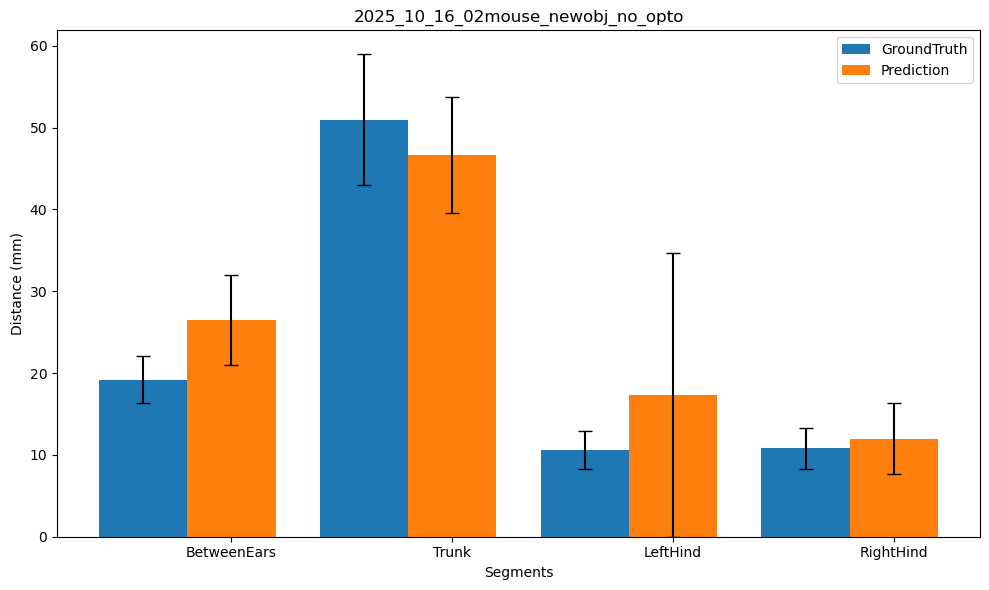

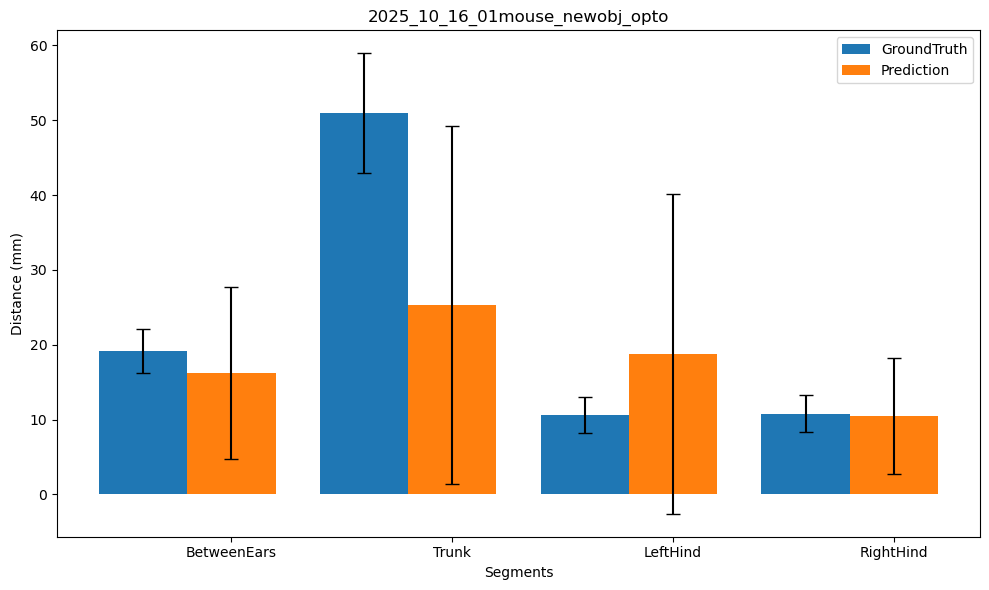

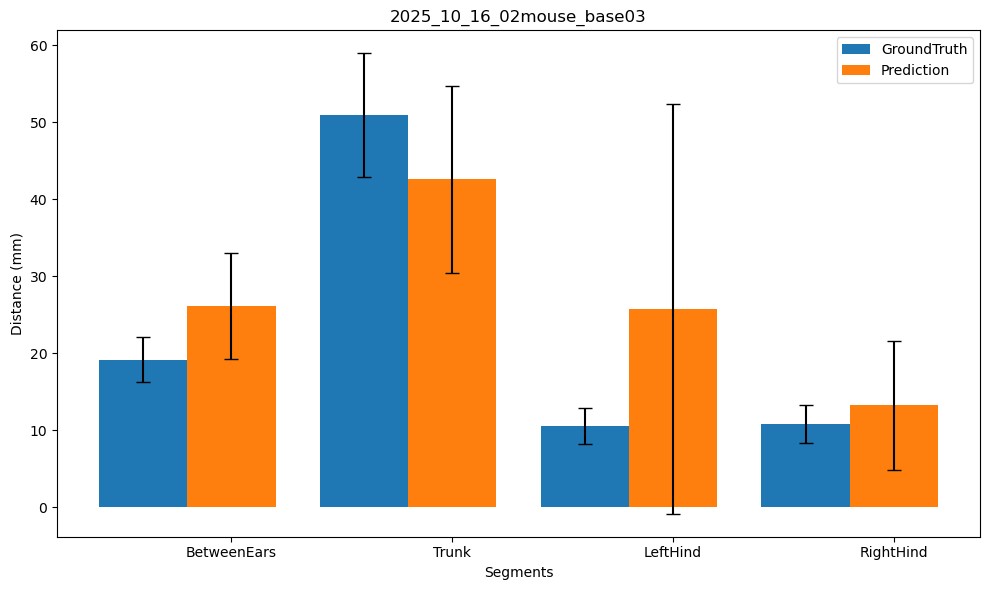

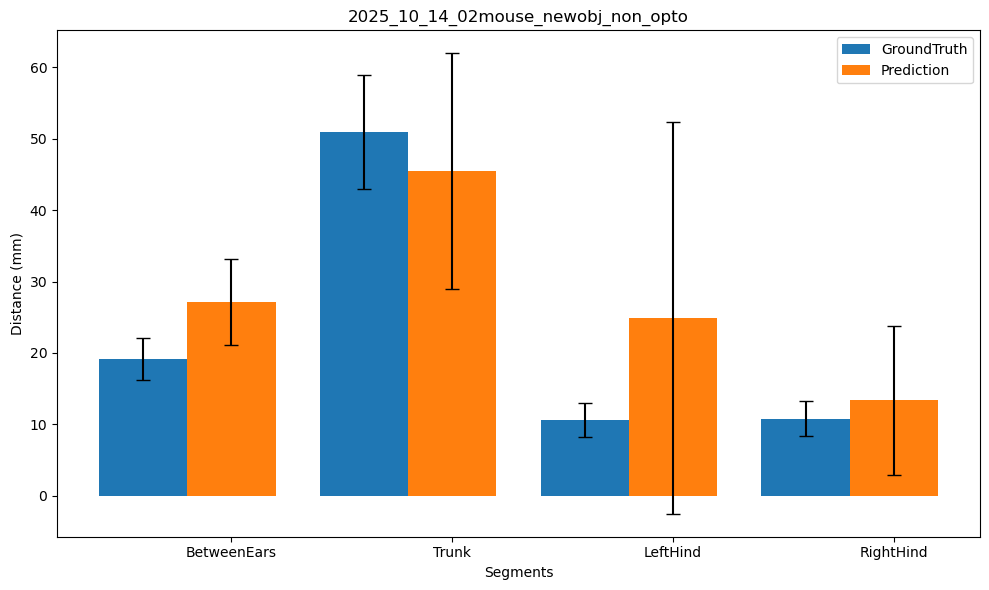

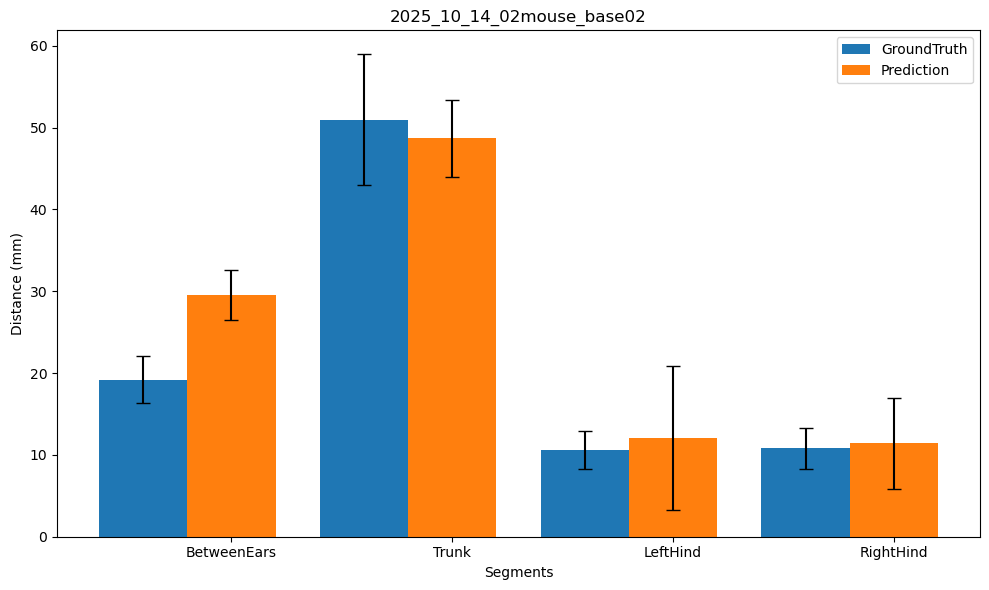

In [12]:
# single dannce valid


from useful_files.sophie_check_dannce_mir_modif import dannce_valid

for_dannce_vis = for_com


records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce_vis['date_folder'], for_dannce_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     try:
#         dannce_valid(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False
#     except Exception as e:
#         print(f" An error occurred while processing {base_path}: {e}")
#         # Skip to the next record if an error occurs
#         continue

# #trying for parallel processing again:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_record(record):
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    try:
        dannce_valid(base_path)
    except Exception as e:
        print(f"An error occurred while processing {base_path}: {e}")
        # Skip to the next record if an error occurs
        pass

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_record, record) for record in records]
    for future in as_completed(futures):
        pass  # You can retrieve results or handle exceptions here if needed
